In [ ]:
import pickle
import scipy as sp
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from bioinfokit import analys, visuz
import scanpy as sc
import bbknn
from samalg import SAM
from samalg.gui import SAMGUI
import samalg.utilities as ut
from matplotlib.pyplot import rc_context
from numba import njit
from numba import prange
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
from tqdm import tqdm
from IPython.display import display_html
from scipy.sparse import issparse
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd
import matplotlib

def display2(*args):
    html_str=''
    for df in args:
        html_str+=df.to_html()
    display_html(html_str.replace('table','table style="display:inline"'),raw=True)

## Figure 3g

In [50]:
predict_motif = pd.read_csv('/media/gary/extdrv/Jesse/CrossSpeciesMappings/all_species_motif_matthews_withshuffle_20250825.csv',index_col=0 )

In [51]:
predict_motif

,Species,CellType,Tissue,Features,Matthews
0,Mlig,Anchor Cells,NaN,MotifDevs,1.000000
1,Mlig,Anchor Cells,NaN,MotifDevs,1.000000
2,Mlig,Anchor Cells,NaN,MotifDevs,1.000000
3,Mlig,Anchor Cells,NaN,MotifDevs,1.000000
4,Mlig,Anchor Cells,NaN,MotifDevs,1.000000
...,...,...,...,...,...
2635,Sman,Vitellocytes,NaN,Shuffle,-0.035353
2636,Sman,Vitellocytes,NaN,Shuffle,-0.022098
2637,Sman,Vitellocytes,NaN,Shuffle,-0.022098
2638,Sman,Vitellocytes,NaN,Shuffle,-0.031496


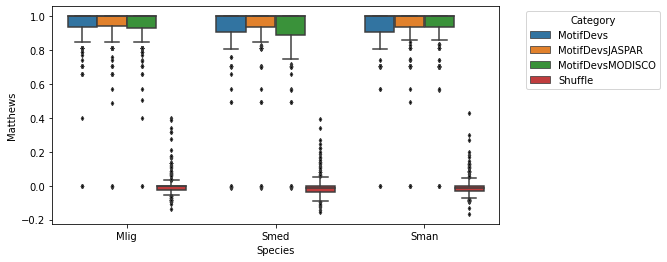

In [55]:
plt.figure(figsize=(8, 4))  # width=10, height=6 inches

sns.boxplot( data=predict_motif, y='Matthews', hue='Features', x='Species',flierprops=dict( markersize=3, markerfacecolor='black', alpha=1) )
plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),  # x, y position relative to axes
    loc='upper left'
)
plt.show()

## Figure 3j

In [3]:
all_species = np.load('all_species_tissue_binned_markers_20250806.npy')
all_species.shape

(10, 1269, 3)

In [5]:
# counts per (motif, species)
motif_counts = (all_species == 1).sum(axis=0)    # (1269, 3)

# threshold for each species
species_thresh = np.array([10, 10, 10])            # shape (3,)

# compare motif counts to species-specific thresholds
keep_mask = motif_counts <= species_thresh       # broadcasts → (1269, 3)

# expand to (celltype, motif, species)
mask3d = keep_mask[None, :, :]

# apply filter
all_species_filtered = np.where(mask3d, all_species, 0)

In [6]:
# Mlig list 
celltype_fam = ['Epidermal', 'Germline', 'Intestine', 'Muscle', 'Neoblast',
       'Neural', 'Neural-POU4', 'Protonephridia', 'Cathepsin',
       'Parenchymal']

motif = sc.read_h5ad("./ChromVARDeivations/Mlig.SEACells_devs.h5ad")
motif_list = .var_names.tolist()

Mlig_arr = all_species_filtered[:, :, 0]  # Take the 0th slice along the 3rd dimension

# Create DataFrame
Mlig_df = pd.DataFrame(Mlig_arr, index=celltype_fam, columns=motif_list)

selected_cell_types = [
    'Epidermal', 'Intestine', 'Muscle', 'Neoblast',
    'Neural', 'Protonephridia', 'Cathepsin'
]

# Dictionary to store results
motifs_with_1 = {}

# Iterate through each selected cell type
for cell_type in selected_cell_types:
    # Get the row, compare to 1, then get column names (motifs) where value is 1
    motifs = Mlig_df.columns[Mlig_df.loc[cell_type] == 1].tolist()
    motifs_with_1[cell_type] = motifs
    
Mlig_epidermal = motifs_with_1["Epidermal"]
Mlig_intestine = motifs_with_1["Intestine"]
Mlig_muscle = motifs_with_1["Muscle"]
Mlig_neoblast = motifs_with_1["Neoblast"]
Mlig_neural = motifs_with_1["Neural"]
Mlig_proto = motifs_with_1["Protonephridia"]
Mlig_cathepsin = motifs_with_1["Cathepsin"]

In [7]:
Smed_arr = all_species_filtered[:, :, 2]  # Take the 0th slice along the 3rd dimension

# Create DataFrame
Smed_df = pd.DataFrame(Smed_arr, index=celltype_fam, columns=motif_list)

selected_cell_types = [
    'Epidermal', 'Intestine', 'Muscle', 'Neoblast',
    'Neural', 'Protonephridia', 'Cathepsin'
]

# Dictionary to store results
motifs_with_1 = {}

# Iterate through each selected cell type
for cell_type in selected_cell_types:
    # Get the row, compare to 1, then get column names (motifs) where value is 1
    motifs = Smed_df.columns[Smed_df.loc[cell_type] == 1].tolist()
    motifs_with_1[cell_type] = motifs
    
Smed_epidermal = motifs_with_1["Epidermal"]
Smed_intestine = motifs_with_1["Intestine"]
Smed_muscle = motifs_with_1["Muscle"]
Smed_neoblast = motifs_with_1["Neoblast"]
Smed_neural = motifs_with_1["Neural"]
Smed_proto = motifs_with_1["Protonephridia"]
Smed_cathepsin = motifs_with_1["Cathepsin"]

In [8]:
Sman_arr = all_species_filtered[:, :, 1]  # Take the 0th slice along the 3rd dimension

# Create DataFrame
Sman_df = pd.DataFrame(Sman_arr, index=celltype_fam, columns=motif_list)

selected_cell_types = [
    'Epidermal', 'Intestine', 'Muscle', 'Neoblast',
    'Neural', 'Protonephridia', 'Cathepsin'
]

# Dictionary to store results
motifs_with_1 = {}

# Iterate through each selected cell type
for cell_type in selected_cell_types:
    # Get the row, compare to 1, then get column names (motifs) where value is 1
    motifs = Sman_df.columns[Sman_df.loc[cell_type] == 1].tolist()
    motifs_with_1[cell_type] = motifs
    
Sman_epidermal = motifs_with_1["Epidermal"]
Sman_intestine = motifs_with_1["Intestine"]
Sman_muscle = motifs_with_1["Muscle"]
Sman_neoblast = motifs_with_1["Neoblast"]
Sman_neural = motifs_with_1["Neural"]
Sman_proto = motifs_with_1["Protonephridia"]
Sman_cathepsin = motifs_with_1["Cathepsin"]

In [9]:
# Making the barplot
Mlig_dict = {
    "Epidermal": Mlig_epidermal,
    "Intestine": Mlig_intestine,
    "Muscle": Mlig_muscle,
    "Neoblast": Mlig_neoblast,
    "Neural": Mlig_neural,
    "Protonephridia": Mlig_proto,
    "Cathepsin": Mlig_cathepsin
}

Smed_dict = {
    "Epidermal": Smed_epidermal,
    "Intestine": Smed_intestine,
    "Muscle": Smed_muscle,
    "Neoblast": Smed_neoblast,
    "Neural": Smed_neural,
    "Protonephridia": Smed_proto,
    "Cathepsin": Smed_cathepsin
}

Sman_dict = {
    "Epidermal": Sman_epidermal,
    "Intestine": Sman_intestine,
    "Muscle": Sman_muscle,
    "Neoblast": Sman_neoblast,
    "Neural": Sman_neural,
    "Protonephridia": Sman_proto,
    "Cathepsin": Sman_cathepsin
}

conserved_dict = {
    "Epidermal": epidermal_conserved,
    "Intestine": intestine_conserved,
    "Muscle": muscle_conserved,
    "Neoblast": neoblast_conserved,
    "Neural": neural_conserved,
    "Protonephridia": proto_conserved,
    "Cathepsin": cathepsin_conserved
}

cell_type_families = [
    "Epidermal", "Intestine", "Muscle", "Neoblast",
    "Neural", "Protonephridia", "Cathepsin"
]

# Placeholder example — repeat for Smed_dict and Sman_dict
species_dicts = {
    "Mlig": Mlig_dict,
    "Smed": Smed_dict,
    "Sman": Sman_dict
}

# Collect counts
plot_data = {
    "Cell Type": [],
    "Species": [],
    "Count": []
}

for cell_type in cell_type_families:
    conserved = set(conserved_dict[cell_type])
    for species, motifs_dict in species_dicts.items():
        motifs = motifs_dict[cell_type]
        species_specific = [m for m in motifs if m not in conserved]
        plot_data["Cell Type"].append(cell_type)
        plot_data["Species"].append(species)
        plot_data["Count"].append(len(species_specific))

Mlig_dict = {k: set(v) for k, v in Mlig_dict.items()}
Smed_dict = {k: set(v) for k, v in Smed_dict.items()}
Sman_dict = {k: set(v) for k, v in Sman_dict.items()}
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )


In [10]:
celltype_family_conserved_motifs = list(dict.fromkeys(v for values in conserved_dict.values() for v in values))

In [11]:
import numpy as np
import pandas as pd

# families
Mlig_family = ["Epidermal", "Intestine", "Muscle", "Neural", "Protonephridia", "Cathepsin"]
Smed_family = ["Epidermal", "Intestine", "Muscle", "Neural", "Protonephridia", "Cathepsin"]
Sman_family = ["Epidermal", "Intestine", "Muscle", "Neural", "Protonephridia", "Cathepsin"]

# make sure conserved motifs are a set
conserved_motifs = set(celltype_family_conserved_motifs)

# subset each dictionary first
Mlig_dict_sub = {
    k: set(v) & conserved_motifs
    for k, v in Mlig_dict.items()
}

Smed_dict_sub = {
    k: set(v) & conserved_motifs
    for k, v in Smed_dict.items()
}

Sman_dict_sub = {
    k: set(v) & conserved_motifs
    for k, v in Sman_dict.items()
}

# initialize matrices
jaccard_Mlig_Smed = np.zeros((len(Mlig_family), len(Smed_family)))
jaccard_Mlig_Sman = np.zeros((len(Mlig_family), len(Sman_family)))
jaccard_Smed_Sman = np.zeros((len(Smed_family), len(Sman_family)))

# Mlig vs Smed
for i, zr in enumerate(Mlig_family):
    for j, mr in enumerate(Smed_family):
        inter = len(Mlig_dict_sub[zr] & Smed_dict_sub[mr])
        union = len(Mlig_dict_sub[zr] | Smed_dict_sub[mr])
        jaccard_Mlig_Smed[i, j] = inter / union if union > 0 else np.nan

# Mlig vs Sman
for i, zr in enumerate(Mlig_family):
    for j, mr in enumerate(Sman_family):
        inter = len(Mlig_dict_sub[zr] & Sman_dict_sub[mr])
        union = len(Mlig_dict_sub[zr] | Sman_dict_sub[mr])
        jaccard_Mlig_Sman[i, j] = inter / union if union > 0 else np.nan

# Smed vs Sman
for i, zr in enumerate(Smed_family):
    for j, mr in enumerate(Sman_family):
        inter = len(Smed_dict_sub[zr] & Sman_dict_sub[mr])
        union = len(Smed_dict_sub[zr] | Sman_dict_sub[mr])
        jaccard_Smed_Sman[i, j] = inter / union if union > 0 else np.nan

# convert to dataframes
jaccard_Mlig_Smed_df = pd.DataFrame(jaccard_Mlig_Smed, index=Mlig_family, columns=Smed_family)
jaccard_Mlig_Sman_df = pd.DataFrame(jaccard_Mlig_Sman, index=Mlig_family, columns=Sman_family)
jaccard_Smed_Sman_df = pd.DataFrame(jaccard_Smed_Sman, index=Smed_family, columns=Sman_family)

In [13]:
jaccard_Mlig_Smed_rowminmax = (
    jaccard_Mlig_Smed_df
    .sub(jaccard_Mlig_Smed_df.min(axis=1), axis=0)
    .div(
        (jaccard_Mlig_Smed_df.max(axis=1) - jaccard_Mlig_Smed_df.min(axis=1))
        .replace(0, np.nan),   # prevents divide-by-zero
        axis=0
    )
)

jaccard_Mlig_Sman_rowminmax = (
    jaccard_Mlig_Sman_df
    .sub(jaccard_Mlig_Sman_df.min(axis=1), axis=0)
    .div(
        (jaccard_Mlig_Sman_df.max(axis=1) - jaccard_Mlig_Sman_df.min(axis=1))
        .replace(0, np.nan),   # prevents divide-by-zero
        axis=0
    )
)

jaccard_Smed_Sman_rowminmax = (
    jaccard_Smed_Sman_df
    .sub(jaccard_Smed_Sman_df.min(axis=1), axis=0)
    .div(
        (jaccard_Smed_Sman_df.max(axis=1) - jaccard_Smed_Sman_df.min(axis=1))
        .replace(0, np.nan),   # prevents divide-by-zero
        axis=0
    )
)


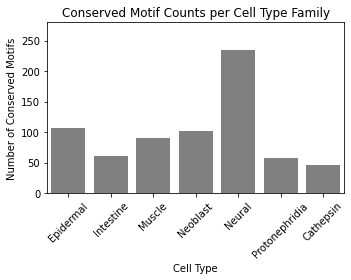

In [45]:
cell_type_families = [
    "Epidermal", "Intestine", "Muscle", "Neoblast",
    "Neural", "Protonephridia", "Cathepsin"
]

# Count number of conserved motifs in each family
conserved_counts = {
    "Cell Type": [],
    "Count": []
}

for ct in cell_type_families:
    motifs = conserved_dict[ct]
    conserved_counts["Cell Type"].append(ct)
    conserved_counts["Count"].append(len(motifs))
    
df_conserved = pd.DataFrame(conserved_counts)

plt.figure(figsize=(5, 4))
sns.barplot(data=df_conserved, x="Cell Type", y="Count", color="gray")
plt.title("Conserved Motif Counts per Cell Type Family")
plt.ylabel("Number of Conserved Motifs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim([0,280])
plt.show()

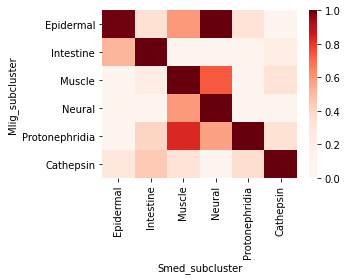

In [30]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(jaccard_Mlig_Smed_rowminmax, cmap=custom_cmap, fmt=".3f", ax=ax)
ax.set_xlabel("Smed_subcluster")
ax.set_ylabel("Mlig_subcluster")
plt.tight_layout()
plt.savefig("./Figures/Figure3/Mlig_Smed_celltype_jaccard_527motifs.svg")

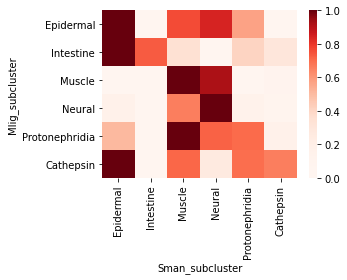

In [31]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(jaccard_Mlig_Sman_rowminmax, cmap=custom_cmap, fmt=".3f", ax=ax)
ax.set_xlabel("Sman_subcluster")
ax.set_ylabel("Mlig_subcluster")
plt.tight_layout()
plt.savefig("./Figures/Figure3/Mlig_Sman_celltype_jaccard_527motifs.svg")

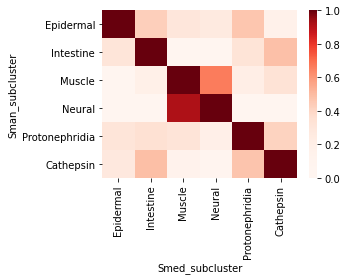

In [32]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(jaccard_Smed_Sman_rowminmax.T, cmap=custom_cmap, fmt=".3f", ax=ax)
ax.set_xlabel("Smed_subcluster")
ax.set_ylabel("Sman_subcluster")
plt.tight_layout()
plt.savefig("./Figures/Figure3/Smed_Sman_celltype_jaccard_527motifs.svg")